In [22]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#Upload the dataset in Google Colab
from google.colab import files

uploaded = files.upload()

Saving amazon_sales_dataset.csv to amazon_sales_dataset (1).csv


In [27]:
#Load the dataset
df = pd.read_csv("amazon_sales_dataset.csv")

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [28]:
#Understand the dataset
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (50000, 13)

Column Names:
['order_id', 'order_date', 'product_id', 'product_category', 'price', 'discount_percent', 'quantity_sold', 'customer_region', 'payment_method', 'rating', 'review_count', 'discounted_price', 'total_revenue']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  disc

In [29]:
#View basic statistics
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [30]:
#Check missing values
print(df.isnull().sum())

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


In [31]:
#Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())
#remove duplicates

Duplicate Rows: 0


In [32]:

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (50000, 13)


In [33]:
#Convert order date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(3)
memory usage: 5.0+ MB


In [34]:
#Create date features
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)
df["day_name"] = df["order_date"].dt.day_name()

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,month_name,year_month,day_name
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,April,2022-04,Wednesday
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,March,2023-03,Sunday
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,September,2022-09,Wednesday
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,April,2022-04,Sunday
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,March,2022-03,Sunday


In [35]:
#Check unique values
print("Product Categories:")
print(df["product_category"].unique())

print("\nCustomer Regions:")
print(df["customer_region"].unique())

print("\nPayment Methods:")
print(df["payment_method"].unique())

Product Categories:
['Books' 'Fashion' 'Sports' 'Beauty' 'Electronics' 'Home & Kitchen']

Customer Regions:
['North America' 'Asia' 'Europe' 'Middle East']

Payment Methods:
['UPI' 'Credit Card' 'Wallet' 'Cash on Delivery' 'Debit Card']


In [36]:
#Calculate important KPIs
total_revenue = df["total_revenue"].sum()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity_sold"].sum()
average_order_value = total_revenue / total_orders
average_rating = df["rating"].mean()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Average Rating:", round(average_rating, 2))

Total Revenue: 32866573.74
Total Orders: 50000
Total Quantity Sold: 149970
Average Order Value: 657.33
Average Rating: 3.0


In [37]:
#Monthly sales trend
monthly_sales = (
    df.groupby("year_month")["total_revenue"]
    .sum()
    .reset_index()
)

print(monthly_sales)

   year_month  total_revenue
0     2022-01     1419751.89
1     2022-02     1266714.29
2     2022-03     1392585.42
3     2022-04     1371955.83
4     2022-05     1374779.57
5     2022-06     1352125.49
6     2022-07     1346089.18
7     2022-08     1449308.06
8     2022-09     1403967.06
9     2022-10     1334818.11
10    2022-11     1291100.05
11    2022-12     1386209.61
12    2023-01     1464174.99
13    2023-02     1238380.51
14    2023-03     1366418.41
15    2023-04     1307017.94
16    2023-05     1431398.77
17    2023-06     1394822.13
18    2023-07     1442176.66
19    2023-08     1396321.88
20    2023-09     1341007.86
21    2023-10     1425936.23
22    2023-11     1334328.47
23    2023-12     1335185.33


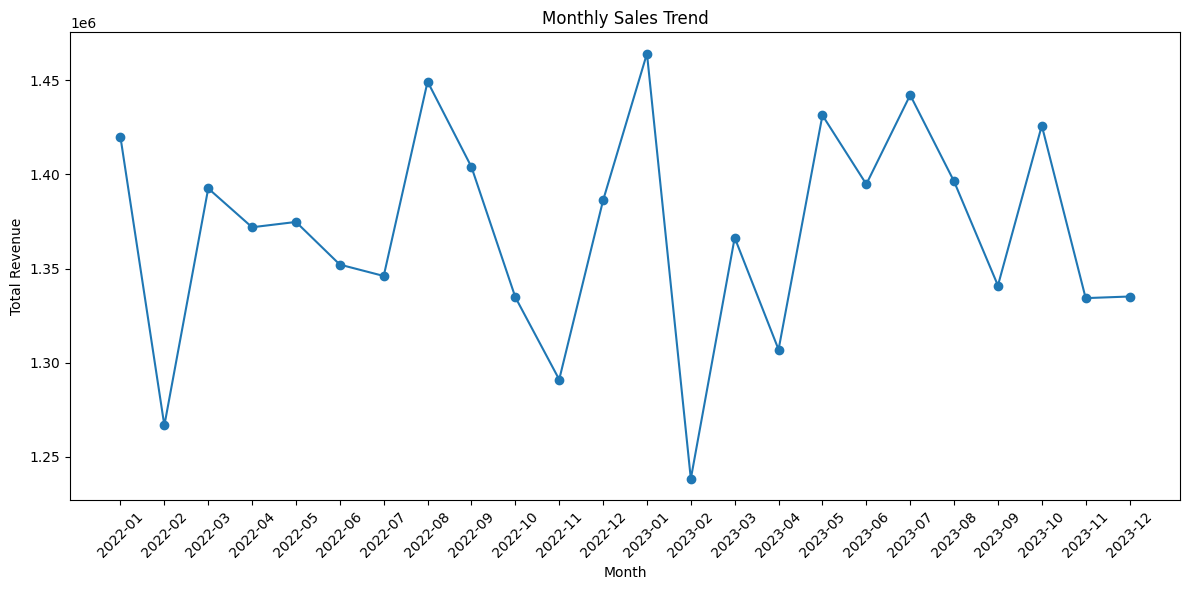

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["year_month"],
    monthly_sales["total_revenue"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
#Revenue by product category
category_sales = (
    df.groupby("product_category")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_sales)

  product_category  total_revenue
0           Beauty     5550624.97
1            Books     5484863.03
2          Fashion     5480123.34
3   Home & Kitchen     5473132.55
4      Electronics     5470594.03
5           Sports     5407235.82


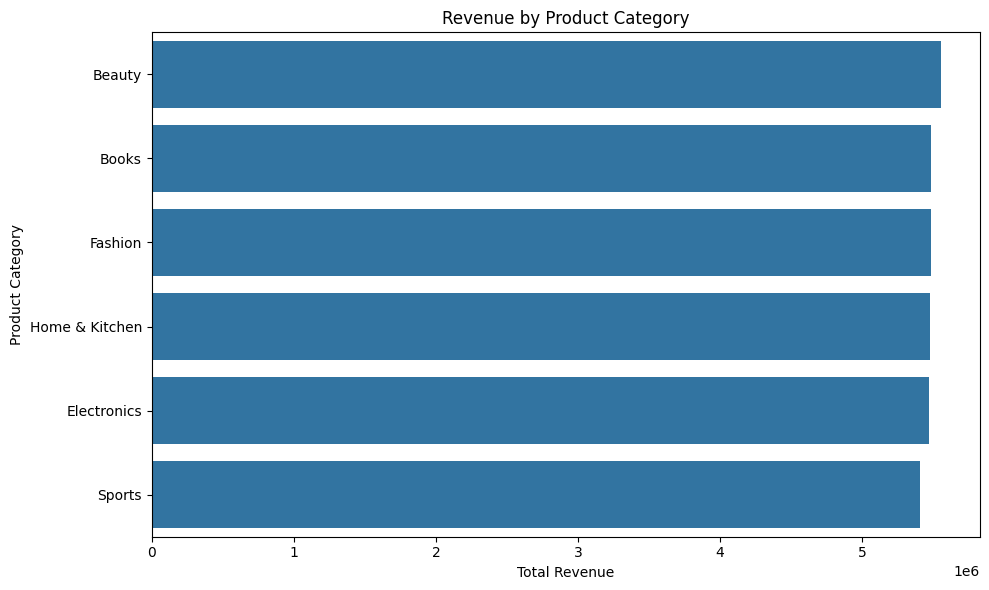

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x="total_revenue",
    y="product_category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [41]:
#Quantity sold by product category
category_quantity = (
    df.groupby("product_category")["quantity_sold"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_quantity)

  product_category  quantity_sold
0           Beauty          25422
1          Fashion          25089
2            Books          25065
3      Electronics          24898
4           Sports          24753
5   Home & Kitchen          24743


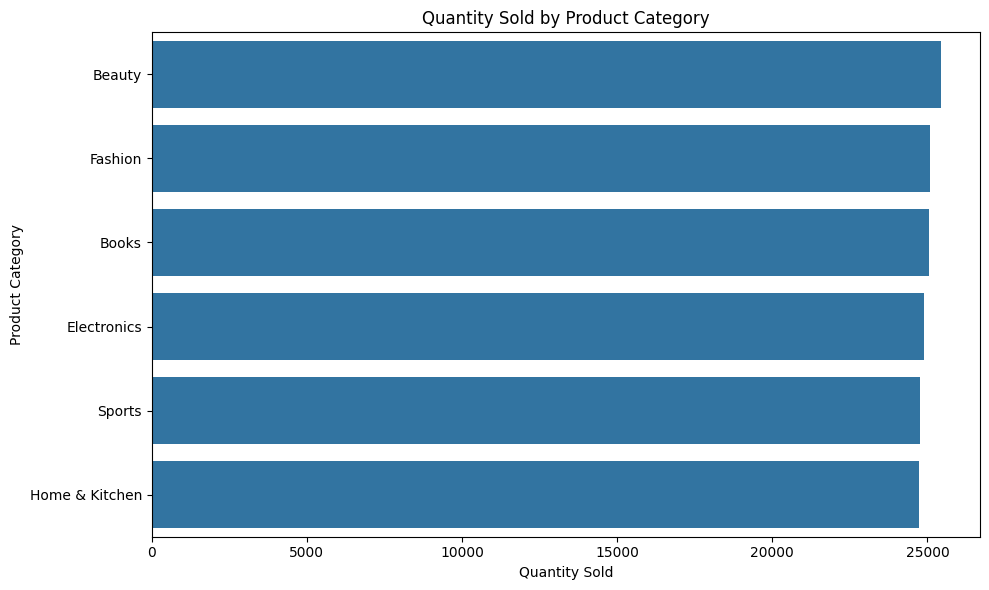

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_quantity,
    x="quantity_sold",
    y="product_category"
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [43]:
#Revenue by customer region
region_sales = (
    df.groupby("customer_region")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(region_sales)

  customer_region  total_revenue
0     Middle East     8301844.50
1   North America     8277217.84
2            Asia     8175199.83
3          Europe     8112311.57


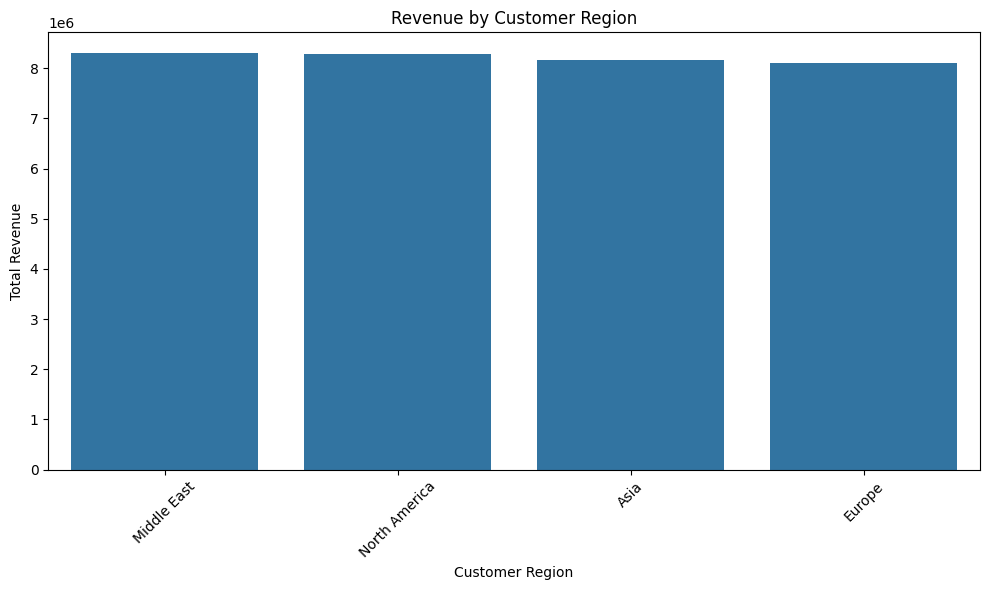

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_sales,
    x="customer_region",
    y="total_revenue"
)

plt.title("Revenue by Customer Region")
plt.xlabel("Customer Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
#Payment method analysis
payment_analysis = (
    df.groupby("payment_method")
    .agg(
        Total_Orders=("order_id", "nunique"),
        Total_Revenue=("total_revenue", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)

print(payment_analysis)

     payment_method  Total_Orders  Total_Revenue
0            Wallet         10106     6678638.47
1               UPI         10078     6579441.44
2  Cash on Delivery          9927     6546386.94
3       Credit Card          9908     6540087.16
4        Debit Card          9981     6522019.73


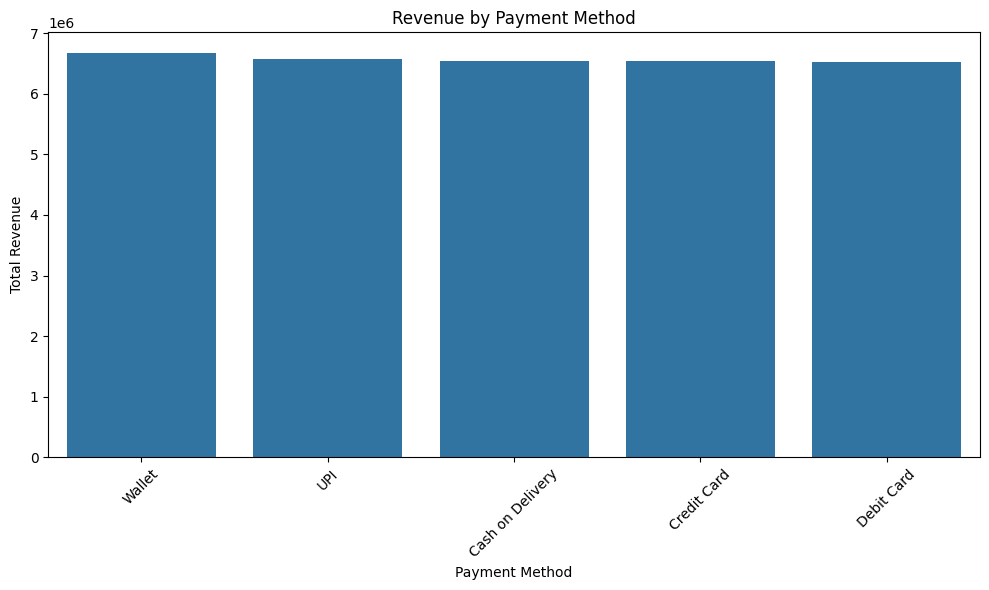

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_analysis,
    x="payment_method",
    y="Total_Revenue"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
#Top 10 products by revenue

top_products = (
    df.groupby("product_id")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_products)

   product_id  total_revenue
0        1931       18885.83
1        1087       18531.52
2        1328       18306.73
3        3537       18071.02
4        2837       17855.07
5        1266       17819.13
6        4386       17806.08
7        4264       17803.51
8        3700       17619.14
9        3377       17201.38


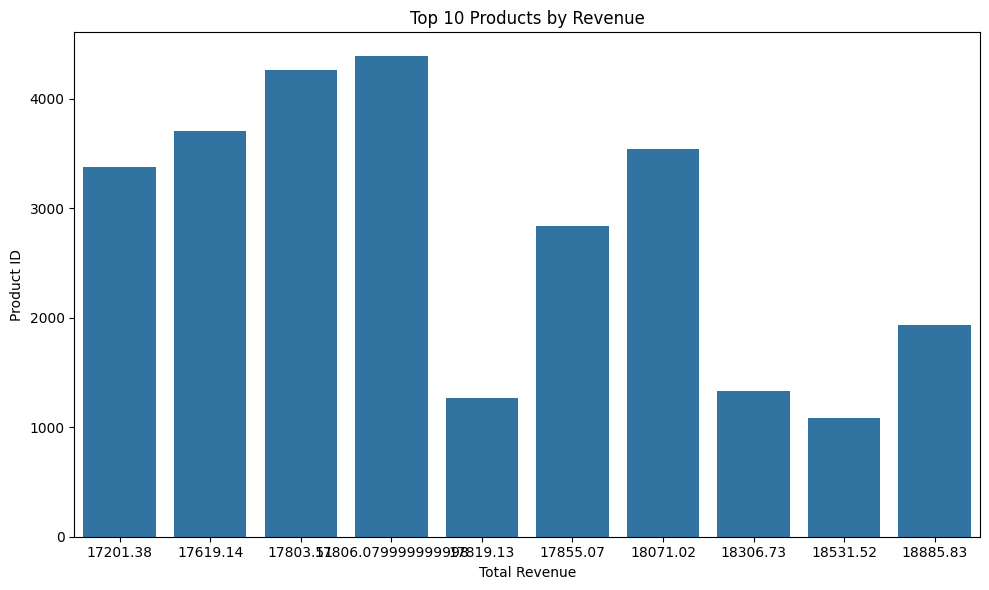

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="total_revenue",
    y="product_id"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()

In [49]:
#Discount analysis
print(df[
    [
        "price",
        "discount_percent",
        "discounted_price",
        "quantity_sold",
        "total_revenue"
    ]
].corr())

                     price  discount_percent  discounted_price  quantity_sold  \
price             1.000000         -0.004654          0.974717       0.004405   
discount_percent -0.004654          1.000000         -0.198713       0.001399   
discounted_price  0.974717         -0.198713          1.000000       0.004457   
quantity_sold     0.004405          0.001399          0.004457       1.000000   
total_revenue     0.711094         -0.144392          0.729694       0.594404   

                  total_revenue  
price                  0.711094  
discount_percent      -0.144392  
discounted_price       0.729694  
quantity_sold          0.594404  
total_revenue          1.000000  


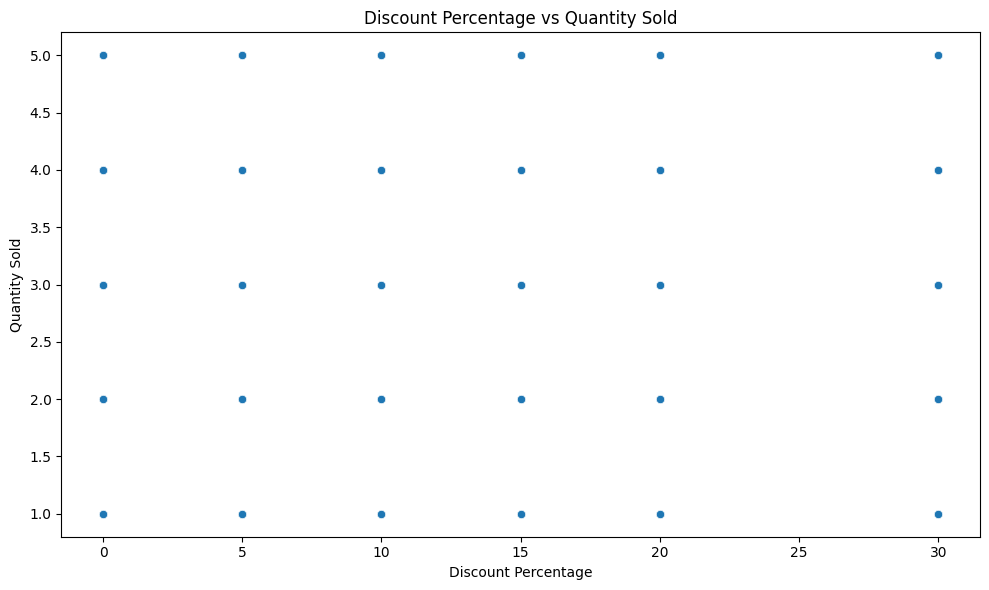

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="quantity_sold"
)

plt.title("Discount Percentage vs Quantity Sold")
plt.xlabel("Discount Percentage")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

In [51]:
#Average rating by category
category_rating = (
    df.groupby("product_category")["rating"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_rating)

  product_category    rating
0            Books  3.020259
1           Sports  2.996891
2   Home & Kitchen  2.996706
3      Electronics  2.991298
4          Fashion  2.987782
5           Beauty  2.985186


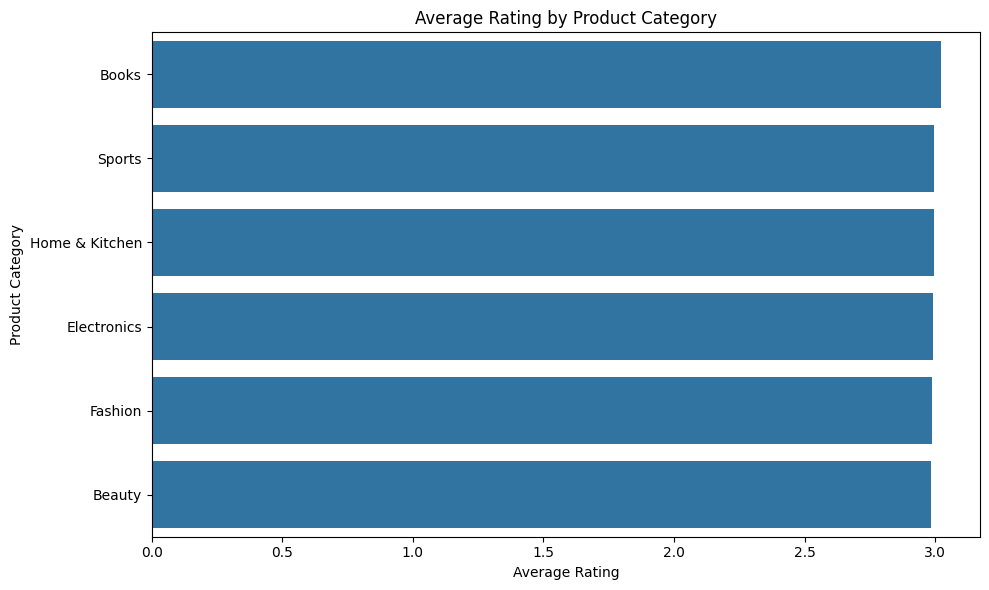

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_rating,
    x="rating",
    y="product_category"
)

plt.title("Average Rating by Product Category")
plt.xlabel("Average Rating")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [53]:
#Review count by category
category_reviews = (
    df.groupby("product_category")["review_count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(category_reviews)

  product_category  review_count
0           Beauty       2095772
1          Fashion       2092536
2   Home & Kitchen       2076392
3           Sports       2074793
4      Electronics       2065438
5            Books       2061533


In [54]:
#Day-of-week sales analysis
day_sales = (
    df.groupby("day_name")["total_revenue"]
    .sum()
    .reset_index()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales["day_name"] = pd.Categorical(
    day_sales["day_name"],
    categories=day_order,
    ordered=True
)

day_sales = day_sales.sort_values("day_name")

print(day_sales)

    day_name  total_revenue
1     Monday     4614737.85
5    Tuesday     4616452.25
6  Wednesday     4621879.23
4   Thursday     4654016.94
0     Friday     4880146.20
2   Saturday     4728529.30
3     Sunday     4750811.97


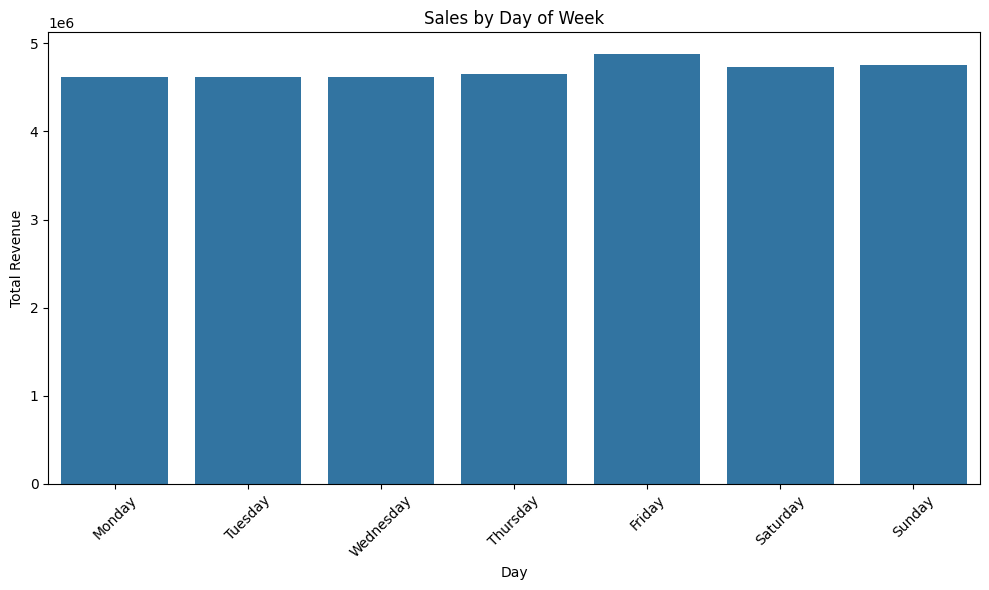

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_sales,
    x="day_name",
    y="total_revenue"
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

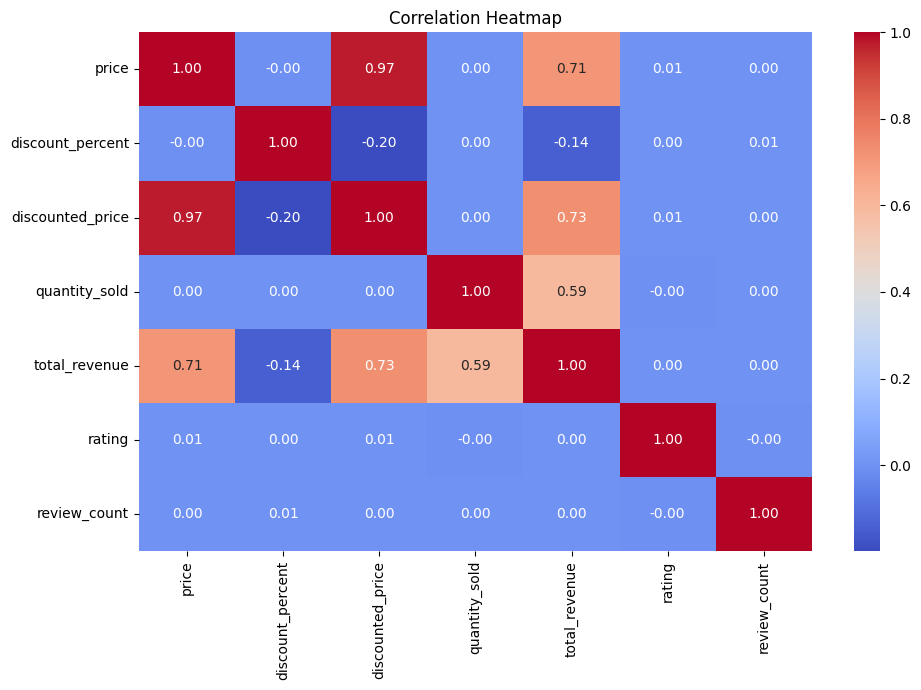

In [56]:
#Correlation heatmap
numeric_columns = [
    "price",
    "discount_percent",
    "discounted_price",
    "quantity_sold",
    "total_revenue",
    "rating",
    "review_count"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [57]:
#Generate a KPI summary
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value",
        "Average Rating"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_quantity,
        round(average_order_value, 2),
        round(average_rating, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,32866573.74
1,Total Orders,50000.00
2,Total Quantity Sold,149970.00
3,Average Order Value,657.33
4,Average Rating,3.00


In [58]:
#Save the cleaned dataset
df.to_csv("cleaned_amazon_sales.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [59]:
from google.colab import files

files.download("cleaned_amazon_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>